# Regressão Linear
Vamos dissecar um modelo de regressão linear para tentar prever o peso de crianças e inferir se o sexo delas influencia em seu peso ao nascer

In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import t

In [28]:
# Dados dos Meninos (Boys)
dados_boys = {
    'Age': [40, 38, 40, 35, 36, 37, 41, 40, 37, 38, 40, 38],
    'Birthweight': [2968, 2795, 3163, 2925, 2625, 2847, 3292, 3473, 2628, 3176, 3421, 2975]
}

# Dados das Meninas (Girls)
dados_girls = {
    'Age': [40, 36, 40, 38, 42, 39, 40, 37, 36, 38, 39, 40],
    'Birthweight': [3317, 2729, 2935, 2754, 3210, 2817, 3126, 2539, 2412, 2991, 2875, 3231]
}

# Criando os DataFrames
df_boys = pd.DataFrame(dados_boys)
df_girls = pd.DataFrame(dados_girls)

In [29]:
df_boys.describe()

,Age,Birthweight
count,12.000000,12.000000
mean,38.333333,3024.000000
std,1.874874,284.218866
min,35.000000,2625.000000
25%,37.000000,2834.000000
50%,38.000000,2971.500000
75%,40.000000,3205.000000
max,41.000000,3473.000000


In [30]:
df_girls.describe()

,Age,Birthweight
count,12.000000,12.000000
mean,38.750000,2911.333333
std,1.815339,280.442291
min,36.000000,2412.000000
25%,37.750000,2747.750000
50%,39.000000,2905.000000
75%,40.000000,3147.000000
max,42.000000,3317.000000


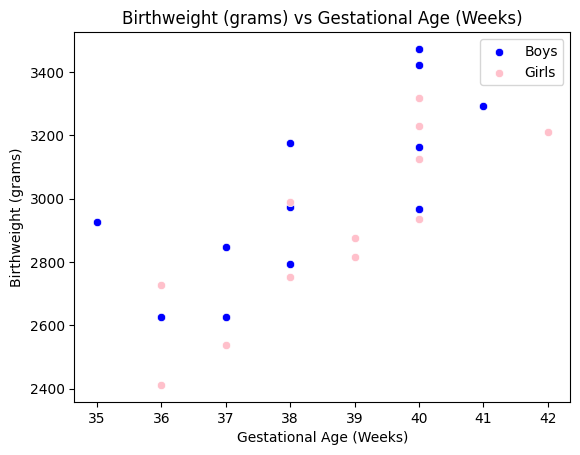

In [31]:
sns.scatterplot(x='Age', y='Birthweight', data=df_boys, label='Boys', color='blue')
sns.scatterplot(x='Age', y='Birthweight', data=df_girls, label='Girls', color='pink')
plt.title('Birthweight (grams) vs Gestational Age (Weeks)')
plt.xlabel('Gestational Age (Weeks)')
plt.ylabel('Birthweight (grams)')
plt.legend()
plt.show()

Sendo $Y_{jk}$ a variável aleatória do peso da criança onde $j = 1$ para meninos e $j=2$ para meninas e $k=1,...,12$. Vamos supor também que os pesos das crianças não interferem entre si, logo são independentes, e que seguem $Y_{jk} \sim \cal{N}(\mu_{jk}, \sigma^2)$, onde a variância é comum a todos. Um modelo bem genérico que podemos montar é:
$$
    \mathbb{E}[Y_{jk}|X_{jk}] = \alpha_j + \beta_j x_{jk}
$$
onde $x_{jk}$ é a idade gestacional em semanas do $k$-ésimo bebê no grupo $j$. Os *intercepts* $\alpha_1$ e $\alpha_2$ vão tender a ser **diferentes** pois a média dos dados mostra que os meninos nascem mais pesados **na média**. Já os parâmetros $\beta_1$ e $beta_2$ representam o incremento médio no peso da criança a cada semana de gestação. Podemos então testar se a taxa de crescimento de ambos os grupos são iguais:
$$
    H_0: \beta = \beta_1 = \beta_2      \\
    H_1: \beta_1 \neq \beta_2
$$
Para testar essas nossas hipóteses, podemos aplicar dois modelos:

$$
    \begin{align}
        \mathbb{E}[Y_{jk}|X_{jk}] = \alpha_j + \beta_j x_{jk}; \space Y_{jk} \sim \cal{N}(\mu_{jk}, \sigma^2)       \\

        \mathbb{E}[Y_{jk}|X_{jk}] = \alpha_j + \beta x_{jk}; \space Y_{jk} \sim \cal{N}(\mu_{jk}, \sigma^2)
    \end{align}
$$

A densidade de probabilidade para $Y_{jk}$ é dada por:
$$
    f(y_{jk}|\mu_{jk}) = \frac{1}{\sqrt{2 \pi \sigma^2}} exp\left[-\frac{1}{2 \sigma^2} (y_{jk} - \mu_{jk})^2\right]
$$

começamos encaixando o momdelo mais geral dado pela segunda equação. A log-verossimilhança é dada por:
$$
    l_1 (\alpha_1, \alpha_2, \beta_1, \beta_2|\underline{y}) = \sum^J_{j=1} \sum^K_{k=1}\left[ -\frac{1}{2} ln(2 \pi \sigma^2) - \frac{1}{2 \sigma^2} (y_{jk} - \mu_{jk})^2 \right]     \\

    = -\frac{1}{2} J K ln(2 \pi \sigma^2) - \frac{1}{2 \sigma^2} \sum^J_{j=1} \sum^K_{k=1} (y_{jk} - \alpha_j - \beta_j x_{jk})^2
$$

no nosso caso, $J=2$ e $K=12$. Estimando esses parâmetros por **máxima verossimilhança**, temos que os parâmetro são os que solucionam essas equações:
$$
    \frac{\partial l_1}{\partial \alpha_j} = \frac{1}{\sigma^2} \sum_{k}(y_{jk} - \alpha_j - \beta_j x_{jk}) = 0        \\
    \frac{\partial l_1}{\partial \beta_j} = \frac{1}{\sigma^2} \sum_{k} x_{jk} (y_{jk} - \alpha_j - \beta_j x_{jk}) = 0
$$

Também podemos minimizar por mínimos quadrados:
$$
    S_1 = \sum_{j=1}^J \sum_{k=1}^K (y_{jk} - \mu_{jk})^2 = \sum_{j=1}^J \sum_{k=1}^K (y_{jk} - \alpha_j - \beta_j x_{jk})^2
$$

e chegamos nas mesmas equações anteriores para a solução. Elas podem ser representado como o sistema matricial:
$$
    \left[
        \begin{matrix}
            n_j  &  \sum_k x_{jk}  \\
            \sum_k x_{jk}  &  \sum_k x_{jk}^2
        \end{matrix}
    \right]
    
    \left[
        \begin{matrix}
            \alpha_j \\
            \beta_j
        \end{matrix}
    \right]

    =

    \left[
        \begin{matrix}
            \sum_k y_{jk} \\
            \sum_k x_{jk} y_{jk}
        \end{matrix}
    \right]
$$

In [32]:
# Resolvendo para j=1 (Meninos)
x1 = df_boys['Age']
y1 = df_boys['Birthweight']
n1 = len(x1)

A = np.array([[n1, np.sum(x1)], [np.sum(x1), np.sum(x1**2)]])
b = np.array([np.sum(y1), np.sum(x1 * y1)])

alpha1, beta1 = np.linalg.solve(A, b)
print(f"Meninos: alpha = {alpha1:.2f}, beta = {beta1:.2f}")

Meninos: alpha = -1268.67, beta = 111.98


In [33]:
# Resolvendo para j=2 (Meninas)
x2 = df_girls['Age']
y2 = df_girls['Birthweight']
n2 = len(x2)

A = np.array([[n2, np.sum(x2)], [np.sum(x2), np.sum(x2**2)]])
b = np.array([np.sum(y2), np.sum(x2 * y2)])

alpha2, beta2 = np.linalg.solve(A, b)
print(f"Meninas: alpha = {alpha2:.2f}, beta = {beta2:.2f}")

Meninas: alpha = -2141.67, beta = 130.40


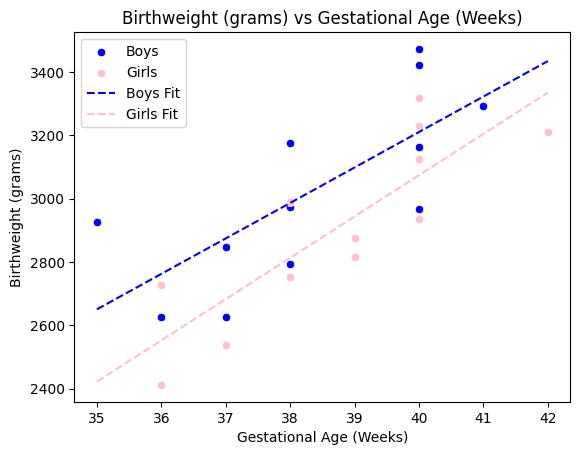

In [34]:
x = np.linspace(min(df_boys['Age'].min(), df_girls['Age'].min()), max(df_boys['Age'].max(), df_girls['Age'].max()), 100)

sns.scatterplot(x='Age', y='Birthweight', data=df_boys, label='Boys', color='blue')
sns.scatterplot(x='Age', y='Birthweight', data=df_girls, label='Girls', color='pink')

plt.plot(x, alpha1 + beta1 * x, label='Boys Fit', color='blue', linestyle='--')
plt.plot(x, alpha2 + beta2 * x, label='Girls Fit', color='pink', linestyle='--')

plt.title('Birthweight (grams) vs Gestational Age (Weeks)')
plt.xlabel('Gestational Age (Weeks)')
plt.ylabel('Birthweight (grams)')
plt.legend()
plt.show()

As soluções para $\alpha_j$ e $\beta_j$ são chamadas de **equações normais**:
$$
    \hat{\beta}_j = \frac{
        K \sum_k x_{jk}y_{jk} - (\sum_k x_{jk})(\sum_k y_{jk})
    }{
        K \sum_k x^2_{jk} - (\sum_k x_{jk})^2
    }   \\

    \hat{\alpha}_j = \overline{y}_j - \beta_j \overline{x}_j
$$